Výsledky úspěšně uloženy do 'vysledky_fyzika_kyvadla.csv'.

Graf úspěšně vygenerován a uložen jako 'graf_kyvadla.png'.


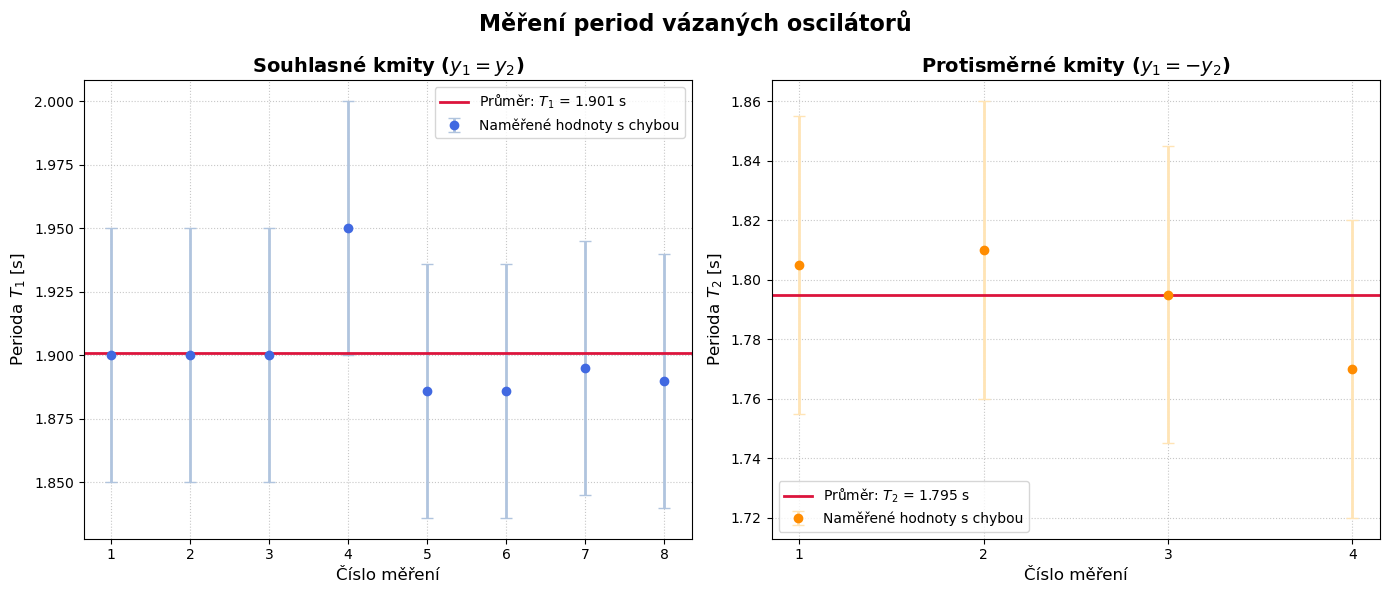

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 1. NASTAVENÍ DAT A VSTUPNÍCH PARAMETRŮ
# ==============================================================================
# Naměřené hodnoty period z tabulky (sekundy)
T1_data = np.array([1.900, 1.900, 1.900, 1.950, 1.886, 1.886, 1.895, 1.890]) # Souhlasné kmity (y1 = y2)
T2_data = np.array([1.805, 1.810, 1.795, 1.770])                           # Protisměrné kmity (y1 = -y2)

# Tuhost pružiny k = 4 N/m (pouze jako poznámka pro protokol, 
# bez znalosti geometrie a hmotnosti kyvadla z ní teoretickou T2 nelze určit)
k = 4.0 

# Nejistota jednotlivého měření (např. reakční doba stopek nebo odhad chyby metody)
nejistota_mereni = 0.05 

# ==============================================================================
# 2. VÝPOČTY PRŮMĚRŮ A STATISTICKÝCH CHYB
# ==============================================================================
# Průměrné hodnoty
T1_mean = np.mean(T1_data)
T2_mean = np.mean(T2_data)

# Směrodatné odchylky jednotlivých měření (výběrové, ddof=1)
T1_std = np.std(T1_data, ddof=1)
T2_std = np.std(T2_data, ddof=1)

# Nejistota průměru (chyba typu A = směrodatná odchylka / sqrt(n))
T1_err = T1_std / np.sqrt(len(T1_data))
T2_err = T2_std / np.sqrt(len(T2_data))

# ==============================================================================
# 3. ZÁKON HROMADĚNÍ CHYB (ERROR PROPAGATION)
# ==============================================================================
# Výpočet úhlových frekvencí: omega = 2*pi / T
omega1 = 2 * np.pi / T1_mean
omega2 = 2 * np.pi / T2_mean

# Derivace d(omega)/dT = -2*pi / T^2. Absolutní hodnota určuje přenos chyby.
omega1_err = (2 * np.pi / T1_mean**2) * T1_err
omega2_err = (2 * np.pi / T2_mean**2) * T2_err

# Výpočet frekvencí rázů podle teoretického zadání
omega3 = 0.5 * (omega2 + omega1)
omega4 = 0.5 * (omega2 - omega1)

# Přenos chyb pro součet/rozdíl nezávislých veličin
omega3_err = 0.5 * np.sqrt(omega1_err**2 + omega2_err**2)
omega4_err = 0.5 * np.sqrt(omega1_err**2 + omega2_err**2)

# Periody rázů (T3 a Ts)
T3 = 2 * np.pi / omega3
T_s = np.pi / omega4  # T_s = pi / omega4 (obálka rázů)

# Přenos chyb pro periodu rázů
T3_err = (2 * np.pi / omega3**2) * omega3_err
T_s_err = (np.pi / omega4**2) * omega4_err

# ==============================================================================
# 4. EXPORT VÝSLEDKŮ DO CSV
# ==============================================================================
results = {
    "Velicina": ["T1 [s]", "T2 [s]", "omega1 [rad/s]", "omega2 [rad/s]", 
                 "omega3 [rad/s]", "omega4 [rad/s]", "T3 [s]", "T_s [s]"],
    "Hodnota": [T1_mean, T2_mean, omega1, omega2, omega3, omega4, T3, T_s],
    "Nejistota": [T1_err, T2_err, omega1_err, omega2_err, omega3_err, omega4_err, T3_err, T_s_err]
}
df_results = pd.DataFrame(results)
df_results.to_csv("vysledky_fyzika_kyvadla.csv", index=False, sep=",")
print("Výsledky úspěšně uloženy do 'vysledky_fyzika_kyvadla.csv'.\n")

# ==============================================================================
# 5. VIZUALIZACE A GENEROVÁNÍ GRAFU (MATPLOTLIB)
# ==============================================================================
# Nastavení stylu grafu
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: T1 (Souhlasné kmity) ---
osa_x1 = range(1, len(T1_data) + 1)
ax1.errorbar(osa_x1, T1_data, yerr=nejistota_mereni, fmt='o', color='royalblue', 
             ecolor='lightsteelblue', elinewidth=2, capsize=4, label='Naměřené hodnoty s chybou')
ax1.axhline(T1_mean, color='crimson', linestyle='-', linewidth=2, label=f'Průměr: $T_1$ = {T1_mean:.3f} s')

ax1.set_title("Souhlasné kmity ($y_1 = y_2$)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Číslo měření", fontsize=12)
ax1.set_ylabel("Perioda $T_1$ [s]", fontsize=12)
ax1.set_xticks(osa_x1)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='best')

# --- Subplot 2: T2 (Protisměrné kmity) ---
osa_x2 = range(1, len(T2_data) + 1)
ax2.errorbar(osa_x2, T2_data, yerr=nejistota_mereni, fmt='o', color='darkorange', 
             ecolor='moccasin', elinewidth=2, capsize=4, label='Naměřené hodnoty s chybou')
ax2.axhline(T2_mean, color='crimson', linestyle='-', linewidth=2, label=f'Průměr: $T_2$ = {T2_mean:.3f} s')

ax2.set_title("Protisměrné kmity ($y_1 = -y_2$)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Číslo měření", fontsize=12)
ax2.set_ylabel("Perioda $T_2$ [s]", fontsize=12)
ax2.set_xticks(osa_x2)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(loc='best')

# Přidání společného nadpisu a uložení
plt.suptitle("Měření period vázaných oscilátorů", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("graf_kyvadla.png", dpi=300, bbox_inches='tight')
print("Graf úspěšně vygenerován a uložen jako 'graf_kyvadla.png'.")

Výsledky úspěšně uloženy do 'vysledky_fyzika_kyvadla.csv'.

      Velicina   Hodnota  Nejistota
        T1 [s]  1.900875   0.050000
        T2 [s]  1.795000   0.050000
omega1 [rad/s]  3.305417   0.086945
omega2 [rad/s]  3.500382   0.097504
omega3 [rad/s]  3.402900   0.065319
omega4 [rad/s]  0.097482   0.065319
        T3 [s]  1.846421   0.035442
       T_s [s] 32.227349  21.594315
Graf úspěšně vygenerován a uložen jako 'graf_kyvadla.png'.


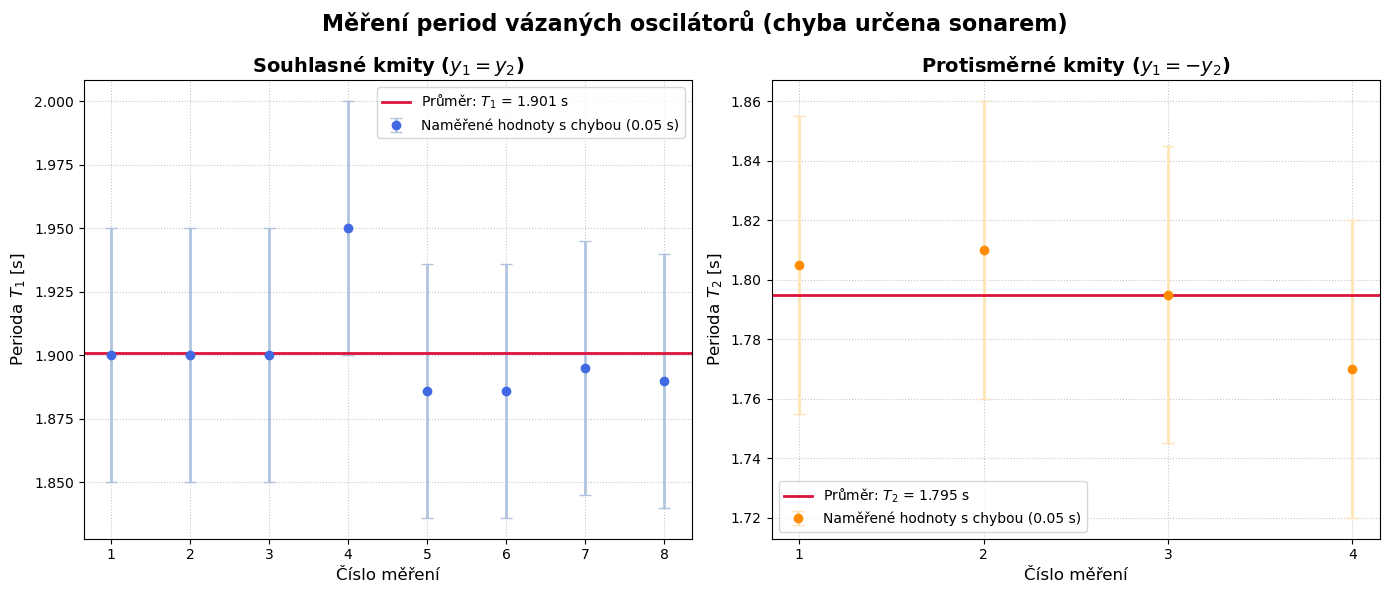

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 1. NASTAVENÍ DAT A VSTUPNÍCH PARAMETRŮ
# ==============================================================================
# Naměřené hodnoty period z tabulky (sekundy)
T1_data = np.array([1.900, 1.900, 1.900, 1.950, 1.886, 1.886, 1.895, 1.890]) # Souhlasné kmity (y1 = y2)
T2_data = np.array([1.805, 1.810, 1.795, 1.770])                           # Protisměrné kmity (y1 = -y2)

# Tuhost pružiny k = 4 N/m
k = 4.0 

# Pevně daná chyba sonaru pro každé jednotlivé měření
chyba_sonaru = 0.05 

# ==============================================================================
# 2. VÝPOČTY PRŮMĚRŮ A PŘÍMÉ DOSAZENÍ CHYBY SONARU
# ==============================================================================
# Průměrné hodnoty
T1_mean = np.mean(T1_data)
T2_mean = np.mean(T2_data)

# Vykašlali jsme se na statistické hromadění chyb (typ A).
# Jako chybu průměru T1 a T2 vezmeme POUZE maximální nejistotu sonaru.
T1_err = chyba_sonaru
T2_err = chyba_sonaru

# ==============================================================================
# 3. PŘENOS CHYB (ERROR PROPAGATION) PRO ODVOZENÉ VELIČINY
# ==============================================================================
# Výpočet úhlových frekvencí: omega = 2*pi / T
omega1 = 2 * np.pi / T1_mean
omega2 = 2 * np.pi / T2_mean

# Derivace d(omega)/dT = -2*pi / T^2. Absolutní hodnota určuje přenos chyby ze sonaru na omegu.
omega1_err = (2 * np.pi / T1_mean**2) * T1_err
omega2_err = (2 * np.pi / T2_mean**2) * T2_err

# Výpočet frekvencí rázů podle teoretického zadání
omega3 = 0.5 * (omega2 + omega1)
omega4 = 0.5 * (omega2 - omega1)

# Přenos chyb pro součet/rozdíl nezávislých veličin přes parciální derivace
omega3_err = 0.5 * np.sqrt(omega1_err**2 + omega2_err**2)
omega4_err = 0.5 * np.sqrt(omega1_err**2 + omega2_err**2)

# Periody rázů (T3 a Ts)
T3 = 2 * np.pi / omega3
T_s = np.pi / omega4  # T_s = pi / omega4 (obálka rázů)

# Přenos chyb pro periodu rázů
T3_err = (2 * np.pi / omega3**2) * omega3_err
T_s_err = (np.pi / omega4**2) * omega4_err

# ==============================================================================
# 4. EXPORT VÝSLEDKŮ DO CSV
# ==============================================================================
results = {
    "Velicina": ["T1 [s]", "T2 [s]", "omega1 [rad/s]", "omega2 [rad/s]", 
                 "omega3 [rad/s]", "omega4 [rad/s]", "T3 [s]", "T_s [s]"],
    "Hodnota": [T1_mean, T2_mean, omega1, omega2, omega3, omega4, T3, T_s],
    "Nejistota": [T1_err, T2_err, omega1_err, omega2_err, omega3_err, omega4_err, T3_err, T_s_err]
}
df_results = pd.DataFrame(results)
df_results.to_csv("vysledky_fyzika_kyvadla.csv", index=False, sep=",")
print("Výsledky úspěšně uloženy do 'vysledky_fyzika_kyvadla.csv'.\n")
print(df_results.to_string(index=False))

# ==============================================================================
# 5. VIZUALIZACE A GENEROVÁNÍ GRAFU (MATPLOTLIB)
# ==============================================================================
# Nastavení stylu grafu
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Subplot 1: T1 (Souhlasné kmity) ---
osa_x1 = range(1, len(T1_data) + 1)
ax1.errorbar(osa_x1, T1_data, yerr=chyba_sonaru, fmt='o', color='royalblue', 
             ecolor='lightsteelblue', elinewidth=2, capsize=4, label='Naměřené hodnoty s chybou (0.05 s)')
ax1.axhline(T1_mean, color='crimson', linestyle='-', linewidth=2, label=f'Průměr: $T_1$ = {T1_mean:.3f} s')

ax1.set_title("Souhlasné kmity ($y_1 = y_2$)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Číslo měření", fontsize=12)
ax1.set_ylabel("Perioda $T_1$ [s]", fontsize=12)
ax1.set_xticks(osa_x1)
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='best')

# --- Subplot 2: T2 (Protisměrné kmity) ---
osa_x2 = range(1, len(T2_data) + 1)
ax2.errorbar(osa_x2, T2_data, yerr=chyba_sonaru, fmt='o', color='darkorange', 
             ecolor='moccasin', elinewidth=2, capsize=4, label='Naměřené hodnoty s chybou (0.05 s)')
ax2.axhline(T2_mean, color='crimson', linestyle='-', linewidth=2, label=f'Průměr: $T_2$ = {T2_mean:.3f} s')

ax2.set_title("Protisměrné kmity ($y_1 = -y_2$)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Číslo měření", fontsize=12)
ax2.set_ylabel("Perioda $T_2$ [s]", fontsize=12)
ax2.set_xticks(osa_x2)
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(loc='best')

# Přidání společného nadpisu a uložení
plt.suptitle("Měření period vázaných oscilátorů (chyba určena sonarem)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("graf_kyvadla.png", dpi=300, bbox_inches='tight')
print("Graf úspěšně vygenerován a uložen jako 'graf_kyvadla.png'.")

w_3 (Přímá z T3): 3.40737 ± 0.09239 rad/s
w_4 (Přímá z Ts): 0.06815 ± 0.00007 rad/s
w3_1 (Nepřímá z T1,T2): 3.40168 ± 0.06519 rad/s
w4_1 (Nepřímá z T1,T2): 0.06969 ± 0.06519 rad/s
Stupeň vazby: 0.04096 ± 0.03823

Graf 'graf_novy_kod_sonar.png' byl úspěšně vygenerován.


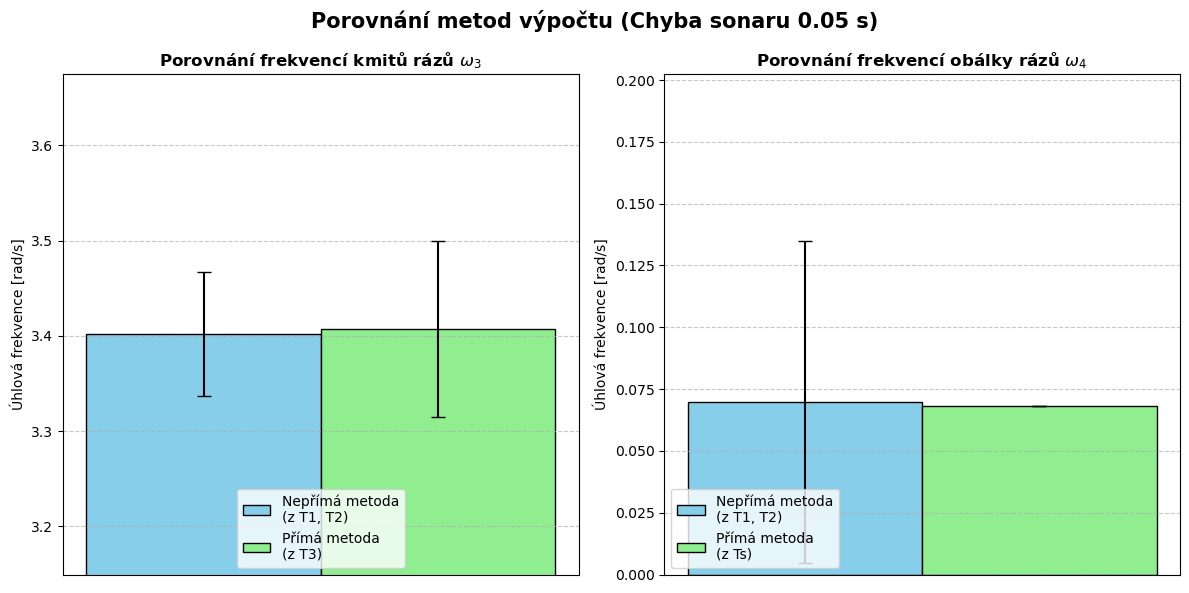

In [10]:
import math
import numpy as np
import matplotlib.pyplot as plt

def pi():
    return 3.141592653589793

# Hodnoty přímo z tvého kódu (v podstatě jde o Polohu 1)
T_3 = 1.844
T_s = 46.1
T_1 = 1.885714
T_2 = 1.81

# ---------------------------------------------------------
# Zadané výpočty (TVŮJ KÓD)
# ---------------------------------------------------------
def w_3():
    return (2*pi())/T_3

def w_4():
    return pi()/T_s

def w_1():
    return (2*pi())/T_1

def w_2():
    return (2*pi())/T_2

def w4_1():
    return 1/2*(w_2()-w_1())

def w3_1():
    return 1/2*(w_1()+w_2())

def stupen_vazby():
    return (w_2()**2-w_1()**2)/(w_2()**2+w_1()**2)

# ---------------------------------------------------------
# VÝPOČET NEJISTOT (Jen přenos jediné chyby sonaru 0.05 s)
# ---------------------------------------------------------
chyba_sonaru = 0.05

# Všechna měření mají stejnou absolutní chybu danou sonarem
err_T1 = chyba_sonaru
err_T2 = chyba_sonaru
err_T3 = chyba_sonaru
err_Ts = chyba_sonaru

# Nejistoty pro vnitřní frekvence w1 a w2 (přes absolutní hodnotu derivace)
err_w1 = (2 * pi() / T_1**2) * err_T1
err_w2 = (2 * pi() / T_2**2) * err_T2

# Nejistoty pro Nepřímou metodu (z w1 a w2) - sčítání přes kvadratický průměr
err_w3_1 = 0.5 * math.sqrt(err_w1**2 + err_w2**2)
err_w4_1 = 0.5 * math.sqrt(err_w1**2 + err_w2**2)

# Nejistoty pro Přímou metodu (z T3 a Ts)
err_w3_2 = (2 * pi() / T_3**2) * err_T3
err_w4_2 = (pi() / T_s**2) * err_Ts

# Nejistota stupně vazby (parciální derivace složeného zlomku)
d_kappa_w1 = (-4 * w_1() * w_2()**2) / ((w_1()**2 + w_2()**2)**2)
d_kappa_w2 = ( 4 * w_1()**2 * w_2()) / ((w_1()**2 + w_2()**2)**2)
err_kappa = math.sqrt((d_kappa_w1 * err_w1)**2 + (d_kappa_w2 * err_w2)**2)

# ---------------------------------------------------------
# VÝPISY VÝSLEDKŮ DO KONZOLE
# ---------------------------------------------------------
print(f"w_3 (Přímá z T3): {w_3():.5f} ± {err_w3_2:.5f} rad/s")
print(f"w_4 (Přímá z Ts): {w_4():.5f} ± {err_w4_2:.5f} rad/s")
print(f"w3_1 (Nepřímá z T1,T2): {w3_1():.5f} ± {err_w3_1:.5f} rad/s")
print(f"w4_1 (Nepřímá z T1,T2): {w4_1():.5f} ± {err_w4_1:.5f} rad/s")
print(f"Stupeň vazby: {stupen_vazby():.5f} ± {err_kappa:.5f}")

# ---------------------------------------------------------
# VYKRESLENÍ POROVNÁVACÍHO GRAFU METOD
# ---------------------------------------------------------
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

bar_width = 0.4
pozice = np.array([0])

# Subplot 1: w3 (Kmit rázů)
ax1.bar(pozice - bar_width/2, [w3_1()], bar_width, yerr=[err_w3_1], label='Nepřímá metoda\n(z T1, T2)', color='skyblue', edgecolor='black', capsize=5)
ax1.bar(pozice + bar_width/2, [w_3()], bar_width, yerr=[err_w3_2], label='Přímá metoda\n(z T3)', color='lightgreen', edgecolor='black', capsize=5)
ax1.set_xticks([]) # Skryje hodnoty na ose x pod sloupcem
ax1.set_title("Porovnání frekvencí kmitů rázů $\omega_3$", fontweight='bold')
ax1.set_ylabel("Úhlová frekvence [rad/s]")
ax1.legend(loc='lower center')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Dynamické nastavení osy Y
max_w3 = max(w3_1() + err_w3_1, w_3() + err_w3_2)
min_w3 = min(w3_1() - err_w3_1, w_3() - err_w3_2)
ax1.set_ylim(min_w3 * 0.95, max_w3 * 1.05)

# Subplot 2: w4 (Obálka rázů)
ax2.bar(pozice - bar_width/2, [w4_1()], bar_width, yerr=[err_w4_1], label='Nepřímá metoda\n(z T1, T2)', color='skyblue', edgecolor='black', capsize=5)
ax2.bar(pozice + bar_width/2, [w_4()], bar_width, yerr=[err_w4_2], label='Přímá metoda\n(z Ts)', color='lightgreen', edgecolor='black', capsize=5)
ax2.set_xticks([])
ax2.set_title("Porovnání frekvencí obálky rázů $\omega_4$", fontweight='bold')
ax2.set_ylabel("Úhlová frekvence [rad/s]")
ax2.legend(loc='lower left')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Dynamické nastavení osy Y
max_w4 = max(w4_1() + err_w4_1, w_4() + err_w4_2)
ax2.set_ylim(0, max_w4 * 1.5)

plt.suptitle("Porovnání metod výpočtu (Chyba sonaru 0.05 s)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("graf_novy_kod_sonar.png", dpi=300)
print("\nGraf 'graf_novy_kod_sonar.png' byl úspěšně vygenerován.")

Výsledky regrese byly uloženy do CSV:
         Parametr   Hodnota  Nejistota
Smernice k [1/cm]  0.004071   0.000073
       Usek q [-] -0.054553   0.002816
Korelacni koef. R  0.999676        NaN

Graf 'graf_regrese_kappa.png' byl úspěšně vygenerován.


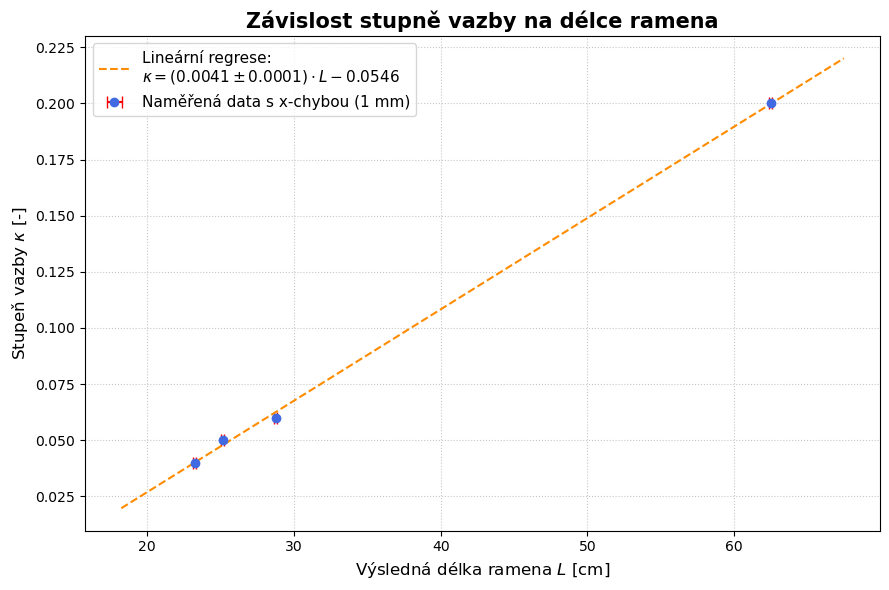

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd

# ==============================================================================
# 1. NASTAVENÍ DAT (Vytaženo z tvé Excel tabulky)
# ==============================================================================
# Výsledná délka ramena (předpoklad: v centimetrech)
L_data = np.array([23.230, 25.136, 28.744, 62.474]) 

# Stupeň vazby (kappa) pro odpovídající polohy
kappa_data = np.array([0.04, 0.05, 0.06, 0.20])

# Chyba měření délky ramena: 1 mm = 0.1 cm
L_err = np.ones_like(L_data) * 0.1 

# ==============================================================================
# 2. VÝPOČET LINEÁRNÍ REGRESE
# ==============================================================================
# linregress z modulu scipy vypočítá směrnici, úsek, R a jejich nejistoty
vysledek = linregress(L_data, kappa_data)

k = vysledek.slope          # Směrnice
k_err = vysledek.stderr     # Chyba směrnice
q = vysledek.intercept      # Posunutí na ose y (úsek)
q_err = vysledek.intercept_stderr # Chyba posunutí
R_hodnota = vysledek.rvalue # Korelační koeficient

# Uložení výsledků do přehledné tabulky CSV
df_regrese = pd.DataFrame({
    "Parametr": ["Smernice k [1/cm]", "Usek q [-]", "Korelacni koef. R"],
    "Hodnota": [k, q, R_hodnota],
    "Nejistota": [k_err, q_err, np.nan]
})
df_regrese.to_csv("vysledky_regrese_kappa.csv", index=False)
print("Výsledky regrese byly uloženy do CSV:")
print(df_regrese.to_string(index=False))

# ==============================================================================
# 3. VYKRESLENÍ GRAFU S REGRESNÍ PŘÍMKOU
# ==============================================================================
# Vytvoření bodů pro plynulé vykreslení teoretické přímky
L_fit = np.linspace(min(L_data) - 5, max(L_data) + 5, 100)
kappa_fit = k * L_fit + q

plt.style.use('default')
fig, ax = plt.subplots(figsize=(9, 6))

# Vynesení experimentálních bodů včetně horizontální chyby (1 mm)
ax.errorbar(L_data, kappa_data, xerr=L_err, fmt='o', color='royalblue', 
            ecolor='red', elinewidth=1.5, capsize=4, 
            label='Naměřená data s x-chybou (1 mm)')

# Vykreslení regresní přímky
rovnice = f"$\\kappa = ({k:.4f} \pm {k_err:.4f}) \cdot L {q:+.4f}$"
ax.plot(L_fit, kappa_fit, color='darkorange', linestyle='--', 
        label=f'Lineární regrese:\n{rovnice}')

# Estetika grafu
ax.set_title("Závislost stupně vazby na délce ramena", fontsize=15, fontweight='bold')
ax.set_xlabel("Výsledná délka ramena $L$ [cm]", fontsize=12)
ax.set_ylabel("Stupeň vazby $\\kappa$ [-]", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='best', fontsize=11)

# Uložení obrázku
plt.tight_layout()
plt.savefig("graf_regrese_kappa.png", dpi=300)
print("\nGraf 'graf_regrese_kappa.png' byl úspěšně vygenerován.")

In [6]:
# Kód vyžaduje instalaci: pip install uncertainties
from uncertainties import ufloat

def pi():
    return 3.141592653589793

print("--- VÝPOČET POMOCÍ KNIHOVNY UNCERTAINTIES ---")

# 1. Definice hodnot včetně chyby sonaru (0.05 s)
# ufloat(hodnota, chyba)
T1 = ufloat(1.885714, 0.05)
T2 = ufloat(1.810000, 0.05)
T3 = ufloat(1.844000, 0.05)
Ts = ufloat(46.100000, 0.05)

# 2. Základní úhlové frekvence
w1 = 2 * 3.141592653589793 / T1
w2 = 2 * 3.141592653589793 / T2

# 3. Metoda 1: Nepřímá (z period samostatných kyvadel)
w3_neprima = 0.5 * (w2 + w1)
w4_neprima = 0.5 * (w2 - w1)

# 4. Metoda 2: Přímá (ze stopování rázů)
w3_prima = 2 * 3.141592653589793 / T3
w4_prima = 3.141592653589793 / Ts

# 5. Stupeň vazby
kappa = (w2**2 - w1**2) / (w2**2 + w1**2)

# Výpis výsledků (Knihovna uncertainties je automaticky zaokrouhlí na správný počet míst)
print(f"Frekvence w1: {w1} rad/s")
print(f"Frekvence w2: {w2} rad/s")
print("-" * 40)
print(f"w3 (nepřímá z T1, T2): {w3_neprima} rad/s")
print(f"w4 (nepřímá z T1, T2): {w4_neprima} rad/s")
print("-" * 40)
print(f"w3 (přímá z T3): {w3_prima} rad/s")
print(f"w4 (přímá z Ts): {w4_prima} rad/s")
print("-" * 40)
print(f"Stupeň vazby kappa:  {kappa}")

--- VÝPOČET POMOCÍ KNIHOVNY UNCERTAINTIES ---
Frekvence w1: 3.33+/-0.09 rad/s
Frekvence w2: 3.47+/-0.10 rad/s
----------------------------------------
w3 (nepřímá z T1, T2): 3.40+/-0.07 rad/s
w4 (nepřímá z T1, T2): 0.07+/-0.07 rad/s
----------------------------------------
w3 (přímá z T3): 3.41+/-0.09 rad/s
w4 (přímá z Ts): 0.06815+/-0.00007 rad/s
----------------------------------------
Stupeň vazby kappa:  0.04+/-0.04
